In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 59.0 MB/s eta 0:00:00


In [3]:
%pip install awkward_pandas

**starting here**

In [21]:
import uproot
import numpy as np
import pandas as pd
import os


file = uproot.open("3merged.root")
os.makedirs("images", exist_ok=True)
tree1 = file["ThreeG_ScannerSCS"]
tree2 = file["ThreeG_ScannerDCS"]
tree3 = file["ThreeG_ScannerTCS"]
tree4 = file["ThreeG_MCS"]
tree5 = file["ThreeG_NCS"]

branches = [
   "EventID",
   "GammaIndex",
   "AnnihilX_mm",
   "AnnihilY_mm",
   "EnergyDeposit_keV"
]

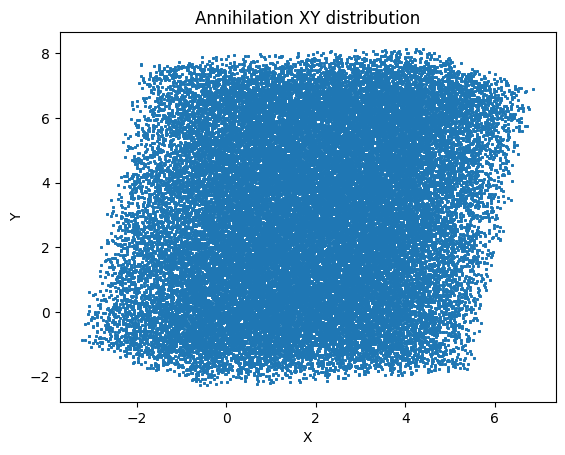

In [10]:
import matplotlib.pyplot as plt
x = tree1["AnnihilX_mm"].array()
y = tree1["AnnihilY_mm"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()

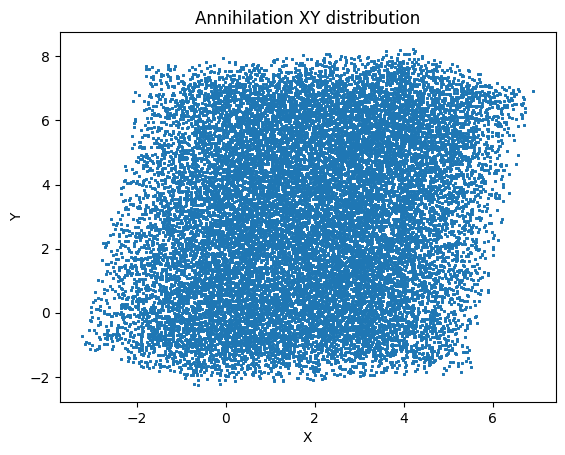

In [11]:
import matplotlib.pyplot as plt
x = tree2["AnnihilX_mm"].array()
y = tree2["AnnihilY_mm"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()#DCS

In [ ]:
import matplotlib.pyplot as plt
x = tree3["AnnihilX_mm"].array()
y = tree3["AnnihilY_mm"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()#tcs

In [24]:
IMG_SIZE = 128

classes = {
    "ThreeG_NCS":0,
    "ThreeG_ScannerSCS":1,
    "ThreeG_ScannerDCS":2,
    "ThreeG_ScannerTCS":3,
    "ThreeG_MCS":4
}

labels = []
image_number = 0

for tree_name, label in classes.items():

    print(f"\nReading {tree_name}")

    tree = file[tree_name]

    for chunk in tree.iterate(
            branches,
            library="pd",
            step_size="20 MB"):

        print(f"Chunk with {len(chunk)} hits")

        for eventID, event in chunk.groupby("EventID"):

            image = np.zeros((IMG_SIZE, IMG_SIZE, 3),
                             dtype=np.float32)

            for gamma in [0,1,2]:

                g = event[event["GammaIndex"] == gamma]

                if len(g) == 0:
                    continue

                H, _, _ = np.histogram2d(

                    g["AnnihilX_mm"],
                    g["AnnihilY_mm"],

                    bins=IMG_SIZE,

                    weights=g["EnergyDeposit_keV"]

                )

                image[:,:,gamma] = H

            np.save(

                f"images/event_{image_number}.npy",

                image

            )

            labels.append(label)

            image_number += 1

        del chunk

print(f"\nFinished!")
print(f"Images saved: {image_number}")


Reading ThreeG_NCS
Chunk with 70962 hits


KeyboardInterrupt: 

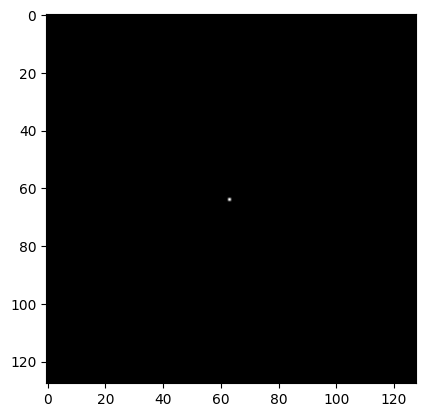

In [26]:
#np.load("images/event_10002.npy")
test_image = np.load("images/event_10.npy")
plt.imshow(test_image)
plt.show()

In [ ]:
labels = np.array(labels)

np.save("labels.npy", labels)

print(labels.shape)

(193841,)


In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

image_files = sorted(os.listdir("images"))
labels = np.load("labels.npy")

In [ ]:
train_files, test_files, train_labels, test_labels = train_test_split(
    image_files,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training images: {len(train_files)}")
print(f"Testing images: {len(test_files)}")

Training images: 155072
Testing images: 38769


In [ ]:
import tensorflow as tf

def load_image(filename, label):

    image = np.load(os.path.join("images", filename.decode()))

    return image.astype(np.float32), label

In [ ]:
def map_func(filename, label):
    image, label = tf.numpy_function(
        load_image,
        [filename, label],
        [tf.float32, tf.int64]
    )
    # Ensure the shape of the tensors
    image = tf.ensure_shape(image, (IMG_SIZE, IMG_SIZE, 3))
    label = tf.ensure_shape(label, ())
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_files, train_labels)
)

train_dataset = train_dataset.map(map_func)

train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_files, test_labels)
)

test_dataset = test_dataset.map(map_func)

test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(64,64,3)),

    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(5,activation="softmax")

])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 249s 50ms/step - accuracy: 0.5835 - loss: 1.1430 - val_accuracy: 0.5852 - val_loss: 1.1403
Epoch 2/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 246s 51ms/step - accuracy: 0.5850 - loss: 1.1164 - val_accuracy: 0.5847 - val_loss: 1.1167
Epoch 3/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 244s 50ms/step - accuracy: 0.5861 - loss: 1.1095 - val_accuracy: 0.5843 - val_loss: 1.1148
Epoch 4/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 229s 47ms/step - accuracy: 0.5888 - loss: 1.1006 - val_accuracy: 0.5824 - val_loss: 1.1234
Epoch 5/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 223s 46ms/step - accuracy: 0.5937 - loss: 1.0904 - val_accuracy: 0.5786 - val_loss: 1.1438
Epoch 6/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 229s 47ms/step - accuracy: 0.6002 - loss: 1.0771 - val_accuracy: 0.5770 - val_loss: 1.1578
Epoch 7/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 227s 47ms/step - accuracy: 0.6055 - loss: 1.0649 - val_accuracy: 0.5725 - val_loss: 1.2348
Epoch 8/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 230s 48ms/step - accuracy: 

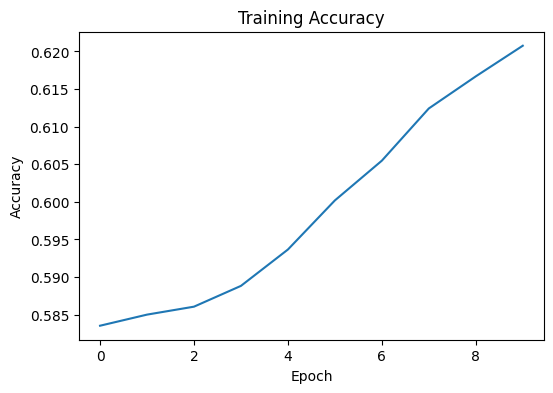

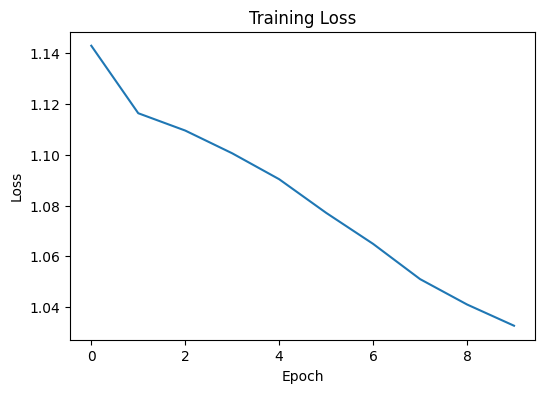

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

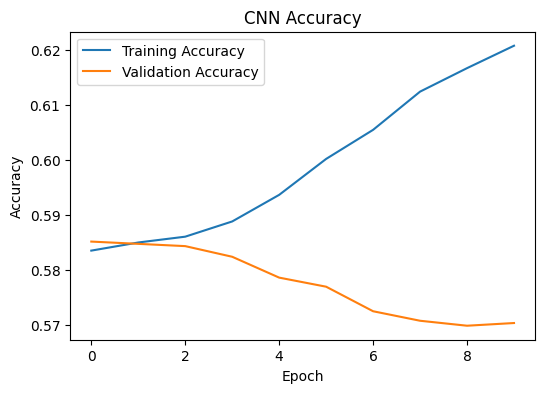

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.show()

In [ ]:
model.save("three_gamma_classifier.keras")

In [ ]:
model = tf.keras.models.load_model("three_gamma_classifier.keras")

In [ ]:
image = np.load("images/event_0.npy")

prediction = model.predict(image[np.newaxis])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.10856514 0.18220112 0.09835587 0.01455981 0.59631807]]


In [ ]:
class_names = [
    "NCS",
    "ScannerSCS",
    "ScannerDCS",
    "ScannerTCS",
    "MCS"
]

predicted = np.argmax(prediction)

print(class_names[predicted])

MCS


**NEW CLASSIFICATION**

In [2]:

# Three-Gamma CNN Regression
# Predict:
#  Annihilation X, Annihilation Y, Annihilation Z, Total deposited energy


import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:

# Load ROOT file


ROOT_FILE = "simulation_job_2.root"

file = uproot.open(ROOT_FILE)

print(file.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1']


In [4]:
branches = [

    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

   EventID  GammaIndex       X_mm       Y_mm       Z_mm  EnergyDeposit_keV  \
0       13           0  -4.246633 -52.294121 -14.782805         319.196869   
1       13           1   6.794903  26.414051 -45.785820         330.648193   
2       13           2   4.653622  39.561180  58.507660         372.152771   
3       54           0 -30.182253   2.519917  40.423599         214.874710   
4       54           1  23.712563  26.669569 -45.202847         481.858032   

   PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  
0     319.196869             0.0     2.943002     7.039147    -7.235910  
1     330.648193             0.0     2.943002     7.039147    -7.235910  
2     372.152771             0.0     2.943002     7.039147    -7.235910  
3     214.874710             0.0    -0.316861     0.007501    -7.923442  
4     481.858032             0.0    -0.316861     0.007501    -7.923442  


In [5]:
print()

print("Number of detector hits =", len(df))

print()

print("Number of events =", df.EventID.nunique())

print()

print(df.describe())


Number of detector hits = 14484

Number of events = 4828

            EventID    GammaIndex          X_mm          Y_mm          Z_mm  \
count  14484.000000  14484.000000  14484.000000  14484.000000  14484.000000   
mean   49405.813380      1.000000      1.069254      2.043001     -5.827464   
std    29000.689145      0.816525     33.096264     33.014416     32.864742   
min       13.000000      0.000000    -89.957039    -89.500664    -95.773674   
25%    24416.750000      0.000000    -26.547538    -25.272101    -33.864635   
50%    48381.500000      1.000000      1.518728      3.153270     -8.776021   
75%    74813.750000      2.000000     29.246635     30.155882     20.369651   
max    99960.000000      2.000000     93.852249     87.361435     97.495903   

       EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV   AnnihilX_mm  \
count       14484.000000   14484.000000         14484.0  14484.000000   
mean          338.513428     338.513428             0.0      1.815278   
std       

In [6]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

print(xmin, xmax)
print(ymin, ymax)

-89.95703887939453 93.85224914550781
-89.50066375732422 87.36143493652344


In [7]:
# ==========================================================
# Create one 3-channel image per event
#
# Channel 0 = EnergyDeposit_keV
# Channel 1 = PreEnergy_keV
# Channel 2 = PostEnergy_keV
#
# Targets:
# X, Y, Z annihilation coordinates
# Total deposited energy
# ==========================================================

images = []
targets = []

event_ids = df.EventID.unique()

print(f"Building images from {len(event_ids)} events...")


for i, event_id in enumerate(event_ids):

    # Select all hits belonging to this event
    event = df[df.EventID == event_id]

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # -----------------------------
    # Channel 0
    # Energy deposited
    # -----------------------------
    H0, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H0


    # -----------------------------
    # Channel 1
    # Incoming energy
    # -----------------------------
    H1, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["PreEnergy_keV"]
    )

    image[:, :, 1] = H1


    # -----------------------------
    # Channel 2
    # Outgoing energy
    # -----------------------------
    H2, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["PostEnergy_keV"]
    )

    image[:, :, 2] = H2


    # -----------------------------
    # Regression Targets
    # -----------------------------

    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    total_energy = event["EnergyDeposit_keV"].sum()


    target = [
        annihil_x,
        annihil_y,
        annihil_z,
        total_energy
    ]


    # -----------------------------
    # Store image and target
    # -----------------------------

    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 4828 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed

Images shape : (4828, 64, 64, 3)
Targets shape: (4828, 4)


In [8]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (4828, 64, 64, 3)
Targets: (4828, 4)

Example target:
[   2.9430022    7.0391474   -7.23591   1021.99786  ]


In [9]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [ ]:
# event = 0

# fig, ax = plt.subplots(1,3, figsize=(18,5))

# titles = [

    # "Energy Deposit",
    # "Pre Energy",
    # "Post Energy"
#
# ]


# for i in range(3):

    # ax[i].imshow(images[event,:,:,i], origin="lower")

    # ax[i].set_title(titles[i])

# plt.show()

In [10]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (4828, 64, 64, 3)
Targets shape: (4828, 4)

First target:
[   2.9430022    7.0391474   -7.23591   1021.99786  ]


In [11]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)


print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training images: (3862, 64, 64, 3)
Testing images: (966, 64, 64, 3)
Training targets: (3862, 4)
Testing targets: (966, 4)


In [12]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-0.37157676 -0.09683175  0.29654533  0.18752167]


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)


model = Sequential()


model.add(
    Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(64,64,3)
    )
)

model.add(MaxPooling2D())


model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())


model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())


model.add(Flatten())


model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.3))


model.add(Dense(4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=25,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.9948 - mae: 0.7082 - val_loss: 0.9998 - val_mae: 0.6947
Epoch 2/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9628 - mae: 0.6999 - val_loss: 0.9308 - val_mae: 0.6873
Epoch 3/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8748 - mae: 0.6824 - val_loss: 0.8318 - val_mae: 0.6745
Epoch 4/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8048 - mae: 0.6681 - val_loss: 0.8370 - val_mae: 0.6748
Epoch 5/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7648 - mae: 0.6544 - val_loss: 0.8145 - val_mae: 0.6653
Epoch 6/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7259 - mae: 0.6408 - val_loss: 0.7725 - val_mae: 0.6526
Epoch 7/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6836 - mae: 0.6255 - val_loss: 0.7935 - val_mae: 0.6611
Epoch 8/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6447 - mae: 0.6066 - val_loss: 0.7883 - val_mae: 0.6587
Epoch 9/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

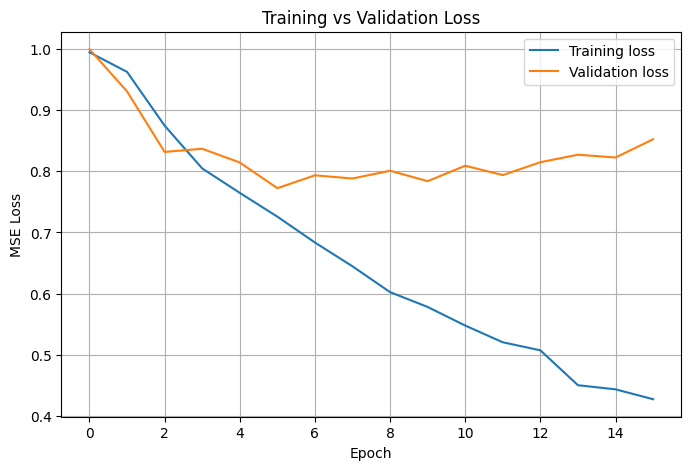

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

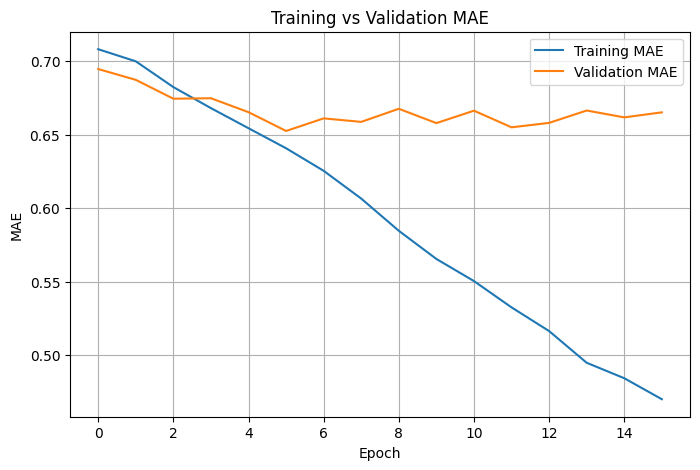

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.grid()

plt.show()

In [18]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test_scaled
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.7347 - mae: 0.6354
Test loss: 0.734714686870575
Test MAE: 0.6354050636291504


In [19]:
prediction_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(prediction_scaled)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [20]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", prediction[i])
    print()

True:      [   2.0544057    4.875222    -5.790002  1021.9978   ]
Predicted: [   1.368024    2.854359   -8.071652 1025.8456  ]

True:      [-7.5329417e-01  4.9522314e+00 -6.0296817e+00  1.0219978e+03]
Predicted: [   2.2207186    2.6406293   -8.688519  1020.5804   ]

True:      [   1.1153466    3.6196966   -8.686705  1021.9978   ]
Predicted: [   1.4126846    3.7113717   -7.696607  1014.8689   ]

True:      [ 3.5807302e+00 -5.6904018e-01 -1.2008869e+01  1.0219978e+03]
Predicted: [   2.0961177    1.9769548   -8.4055195 1008.79193  ]

True:      [ 5.00950861e+00  8.59428346e-01 -1.04217100e+01  1.02199786e+03]
Predicted: [   1.1613894    2.482094    -8.310093  1015.9507   ]



In [21]:
position_error = prediction[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 3.1792238 mm


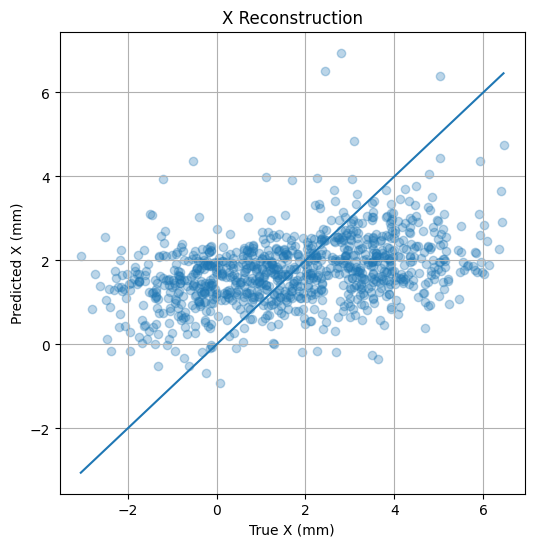

In [22]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

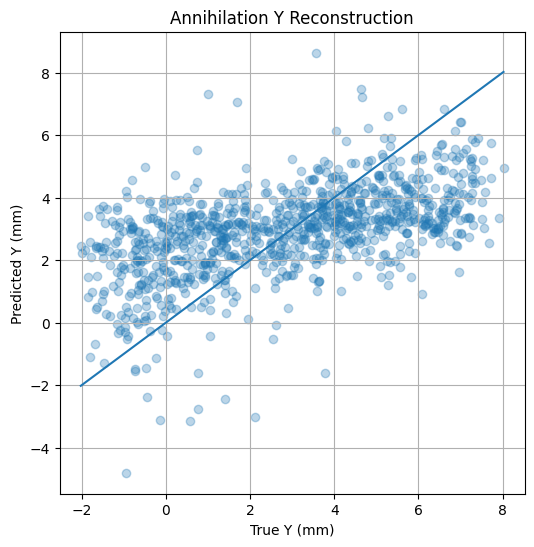

In [23]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    prediction[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

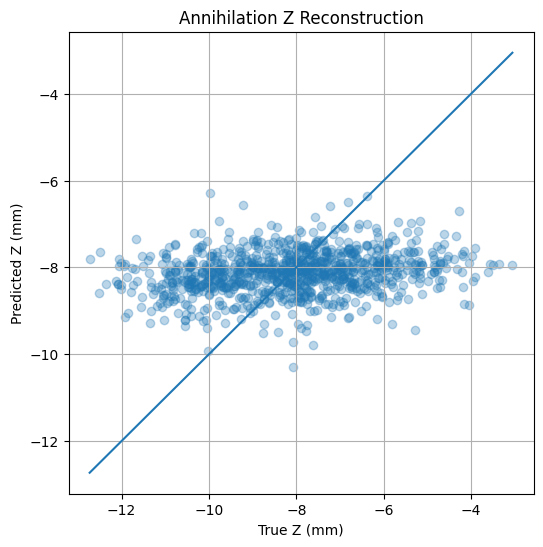

In [24]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    prediction[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

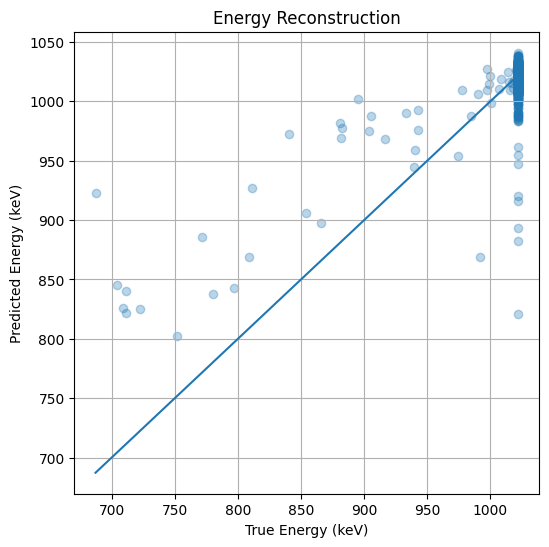

In [25]:
#energy
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,3],          # True energy
    prediction[:,3],      # Predicted energy
    alpha=0.3
)

plt.xlabel("True Energy (keV)")
plt.ylabel("Predicted Energy (keV)")

plt.title("Energy Reconstruction")


plt.plot(
    [y_test[:,3].min(), y_test[:,3].max()],
    [y_test[:,3].min(), y_test[:,3].max()]
)

plt.grid()
plt.show()